# Advanced Banking Intent Classification

## Objective

Build high-performance NLP models for banking intent classification using:
- TF-IDF features
- Character n-grams
- LinearSVC optimization
- Ensemble learning
- Hyperparameter tuning

## Goal

Predict banking intent categories from user questions with maximum possible accuracy.

## Intent Categories

- Basic Accounts
- Digital Banking
- Loans & Interest
- Operations & Security
- General Finance
- Customer Service
- Financial Markets
- Insurance & Govt Schemes
- International Banking
- Banking Terminology

### Import Libraries

In [162]:
# Data manipulation
import pandas as pd
import numpy as np

# Model loading/saving
import pickle

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Preprocessed Data

#### Load Processed Dataset

In [163]:
df = pd.read_csv("../data/banking_processed.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (27930, 8)


,Section,Question,Answer,question_length,answer_length,clean_question,processed_question,label
0,Basic Accounts,What is a Savings Account?,A savings account lets you keep your money saf...,26,119,saving account,what is a savings account,1
1,Basic Accounts,What is a Current Account?,A current account is mainly for businesses. It...,26,123,current account,what is a current account,1
2,Basic Accounts,What is a Fixed Deposit?,A fixed deposit lets you lock in a sum of mone...,24,127,fix deposit,what is a fixed deposit,1
3,Basic Accounts,What does KYC stand for?,KYC stands for Know Your Customer. It's how ba...,24,110,kyc stand,what does kyc stand for,1
4,Basic Accounts,What is a cheque?,A cheque is a written instruction to your bank...,17,106,cheque,what is a cheque,1


### Load Combined Features

#### Load Feature Matrices

In [164]:
with open("../models/X_train_combined.pkl", "rb") as f:
    X_train = pickle.load(f)

with open("../models/X_test_combined.pkl", "rb") as f:
    X_test = pickle.load(f)

print("Combined feature matrices loaded successfully!")

Combined feature matrices loaded successfully!


#### Load Labels

In [165]:
y = df['label']

#### Recreate Train-Test Split

Use same random state to maintain consistency.

In [166]:
from sklearn.model_selection import train_test_split

_, _, y_train, y_test = train_test_split(
    df['processed_question'],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Check Shapes

In [167]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (22344, 15000)
X_test shape: (5586, 15000)


### Baseline Models

We first establish baseline performance.

#### Logistic Regression

In [168]:
# Initialize
log_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Accuracy
log_acc = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.9887218045112782


In [ ]:
# Training accuracy
train_accuracy = best_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = best_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

#### Naive Bayes

In [169]:
# Initialize
nb_model = MultinomialNB()

# Train
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Accuracy
nb_acc = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9269602577873255


In [ ]:
# Training accuracy
train_accuracy = best_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = best_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

#### Random Forest

In [170]:
# Initialize
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9697457930540637


In [ ]:
# Training accuracy
train_accuracy = best_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = best_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

#### Linear SVM

In [171]:
# Initialize
svm_model = LinearSVC(
    C=2,
    class_weight='balanced',
    max_iter=5000
)

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Improved LinearSVC Accuracy:", svm_acc)

Improved LinearSVC Accuracy: 0.9885427855352668


In [ ]:
# Training accuracy
train_accuracy = best_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = best_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

### Hyperparameter Tuning

#### Tune Logistic Regression

In [172]:
# Parameter Grid
log_param_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'solver': ['liblinear']
}

# Grid Search
log_grid = GridSearchCV(

    LogisticRegression(
        class_weight='balanced',
        max_iter=5000
    ),
    param_grid=log_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
log_grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", log_grid.best_params_)
print("Best CV Score:", log_grid.best_score_)

# Best Model
best_log_model = log_grid.best_estimator_

# Predict
y_pred_best_log = best_log_model.predict(X_test)

# Accuracy
best_log_acc = accuracy_score(
    y_test,
    y_pred_best_log
)

print("Best Logistic Regression Accuracy: ", best_log_acc)

Best Parameters: {'C': 5, 'solver': 'liblinear'}
Best CV Score: 0.9891693358384719
Best Logistic Regression Accuracy:  0.9876476906552094


#### Tune LinearSVC

In [173]:
# Parameter Grid
svm_param_grid = {
    'C': [0.1, 0.5, 1, 2, 5, 10]
}

# Grid Search
svm_grid = GridSearchCV(

    LinearSVC(
        class_weight='balanced',
        max_iter=10000
    ),
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
svm_grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", svm_grid.best_params_)
print("Best CV Score:", svm_grid.best_score_)

# Best Model
best_svm = svm_grid.best_estimator_

# Predict
y_pred_best_svm = best_svm.predict(X_test)

# Accuracy
best_svm_acc = accuracy_score(
    y_test,
    y_pred_best_svm
)

print("Best Tuned LinearSVC Accuracy: ", best_svm_acc)

Best Parameters: {'C': 10}
Best CV Score: 0.9901091834668069
Best Tuned LinearSVC Accuracy:  0.9885427855352668


In [ ]:
# Training accuracy
train_accuracy = best_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = best_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

### Cross Validation

This gives more reliable performance estimation.

#### Logistic Regression CV

In [174]:
log_cv_scores = cross_val_score(
    best_log_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Logistic Regression CV Scores: ", log_cv_scores)
print("Average Logistic Regression CV Accuracy: ", log_cv_scores.mean())

Logistic Regression CV Scores:  [0.99172074 0.98858805 0.98858805 0.98814052 0.98880931]
Average Logistic Regression CV Accuracy:  0.9891693358384719


#### LinearSVC CV

In [175]:
svm_cv_scores = cross_val_score(
    best_svm,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("LinearSVC CV Scores: ", svm_cv_scores)
print("Average LinearSVC CV Accuracy: ", svm_cv_scores.mean())

LinearSVC CV Scores:  [0.9926158  0.98948311 0.98881181 0.9901544  0.98970457]
Average LinearSVC CV Accuracy:  0.9901539362079124


### Ensemble Learning

Combine multiple models for better robustness.

In [176]:
# Create Ensemble
ensemble_model = VotingClassifier(

    estimators=[
        ('logistic', best_log_model),
        ('naive_bayes', nb_model),
        ('svm', best_svm)
    ],
    voting='hard'
)

# Train Ensemble
ensemble_model.fit(X_train, y_train)

# Predict
y_pred_ensemble = ensemble_model.predict(X_test)

# Accuracy
ensemble_acc = accuracy_score(
    y_test,
    y_pred_ensemble
)

print("Ensemble Accuracy:", ensemble_acc)

Ensemble Accuracy: 0.9876476906552094


In [ ]:
# Training accuracy
train_accuracy = best_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = best_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

### Model Comparison

#### Accuracy Comparison Table

In [177]:
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Tuned Logistic Regression',
        'Naive Bayes',
        'Random Forest',
        'LinearSVC',
        'Tuned LinearSVC',
        'Ensemble'
    ],

    'Accuracy': [
        log_acc,
        best_log_acc,
        nb_acc,
        rf_acc,
        svm_acc,
        best_svm_acc,
        ensemble_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.988722
1,Tuned Logistic Regression,0.987648
2,Naive Bayes,0.926960
3,Random Forest,0.969746
4,LinearSVC,0.988543
5,Tuned LinearSVC,0.988543
6,Ensemble,0.987648


#### Sort Results

In [178]:
results = results.sort_values(
    by='Accuracy',
    ascending=False
)

results

,Model,Accuracy
0,Logistic Regression,0.988722
4,LinearSVC,0.988543
5,Tuned LinearSVC,0.988543
1,Tuned Logistic Regression,0.987648
6,Ensemble,0.987648
3,Random Forest,0.969746
2,Naive Bayes,0.926960


#### Visualization

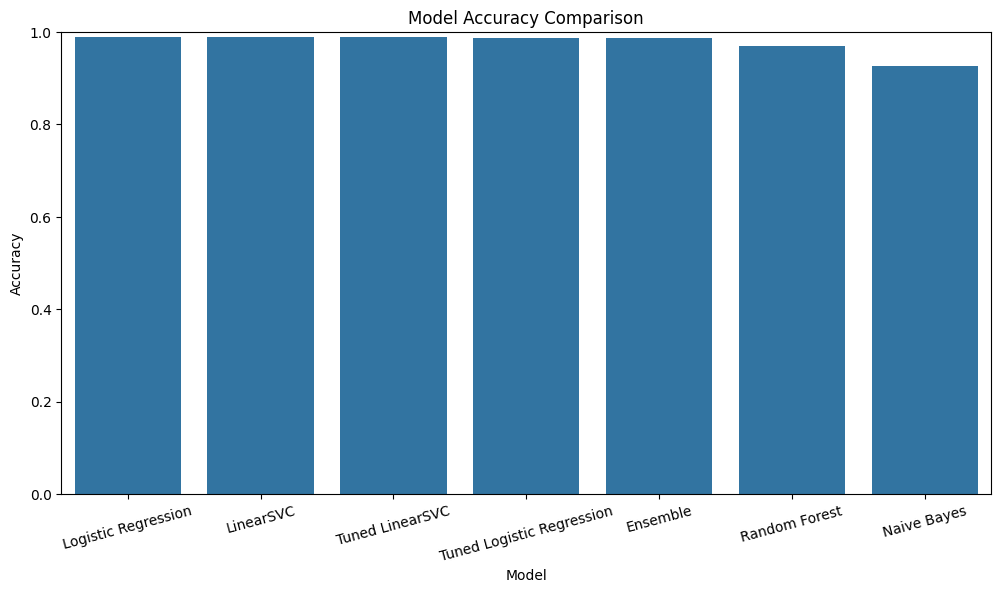

In [179]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.show()

### Automatically Select Best Model

This makes your notebook scalable for future larger datasets.

#### Create Model Dictionary

In [180]:
model_scores = {

    "Logistic Regression": log_acc,
    "Tuned Logistic Regression": best_log_acc,
    "Naive Bayes": nb_acc,
    "Random Forest": rf_acc,
    "LinearSVC": svm_acc,
    "Tuned LinearSVC": best_svm_acc,
    "Ensemble": ensemble_acc
}

#### Best Model Selection

In [181]:
best_model_name = max(
    model_scores,
    key=model_scores.get
)

print("Best Model: ", best_model_name)

Best Model:  Logistic Regression


#### Assign Best Model Automatically

In [182]:
if best_model_name == "Logistic Regression":
    best_model = log_model

elif best_model_name == "Tuned Logistic Regression":
    best_model = best_log_model

elif best_model_name == "Naive Bayes":
    best_model = nb_model

elif best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "LinearSVC":
    best_model = svm_model

elif best_model_name == "Tuned LinearSVC":
    best_model = best_svm

elif best_model_name == "Ensemble":
    best_model = ensemble_model

### Evaluation Metrics

#### Classification Report

In [183]:
best_predictions = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        best_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       493
           1       1.00      0.99      1.00       680
           2       1.00      1.00      1.00       477
           3       0.99      0.97      0.98       652
           4       0.98      0.99      0.98       517
           5       0.97      0.97      0.97       594
           6       0.98      0.99      0.99       493
           7       0.98      0.99      0.98       445
           8       1.00      1.00      1.00       617
           9       1.00      0.99      0.99       618

    accuracy                           0.99      5586
   macro avg       0.99      0.99      0.99      5586
weighted avg       0.99      0.99      0.99      5586



#### Confusion Matrix

In [184]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(
        y_true,
        y_pred
    )
    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

#### Logistic Regression Confusion Matrix

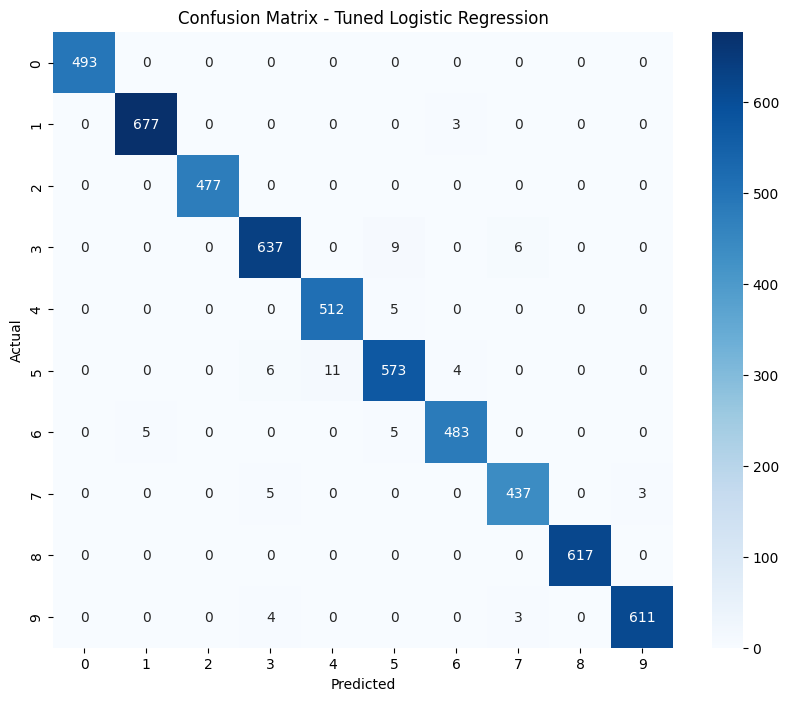

In [185]:
plot_confusion_matrix(
    y_test,
    y_pred_best_log,
    "Confusion Matrix - Tuned Logistic Regression"
)

#### Naive Bayes Confusion Matrix

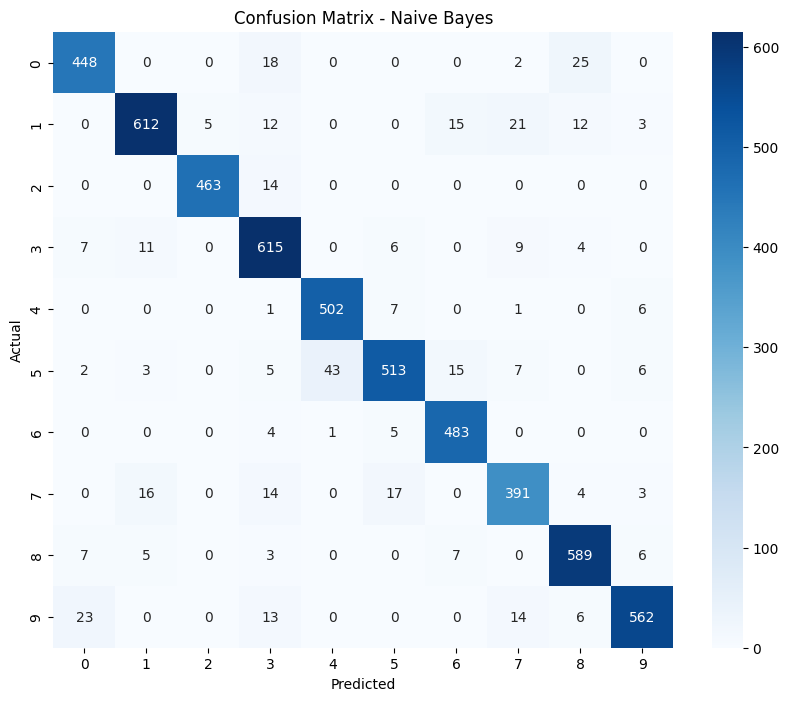

In [186]:
plot_confusion_matrix(
    y_test,
    y_pred_nb,
    "Confusion Matrix - Naive Bayes"
)

#### LinearSVC Confusion Matrix

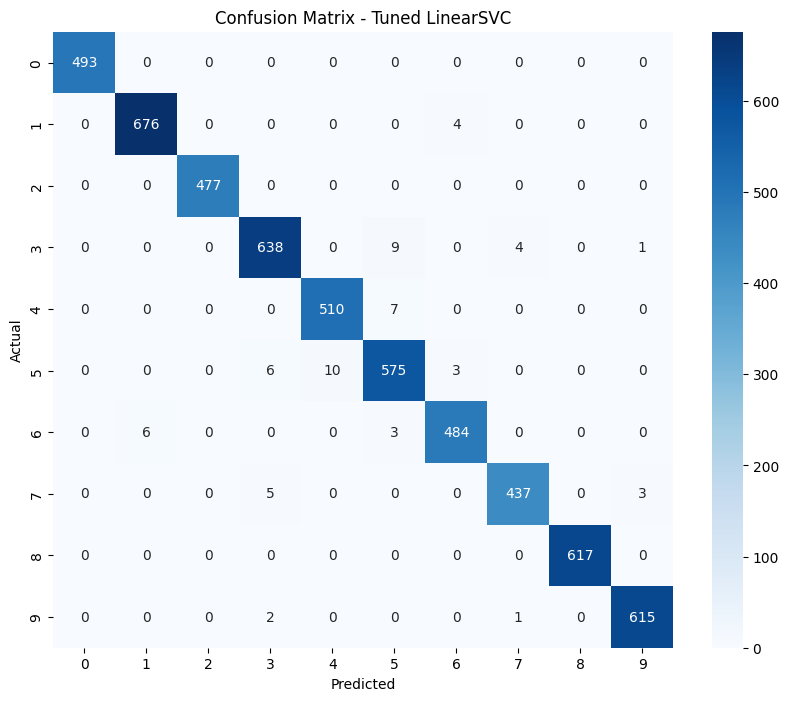

In [187]:
plot_confusion_matrix(
    y_test,
    y_pred_best_svm,
    "Confusion Matrix - Tuned LinearSVC"
)

#### Ensemble Confusion Matrix

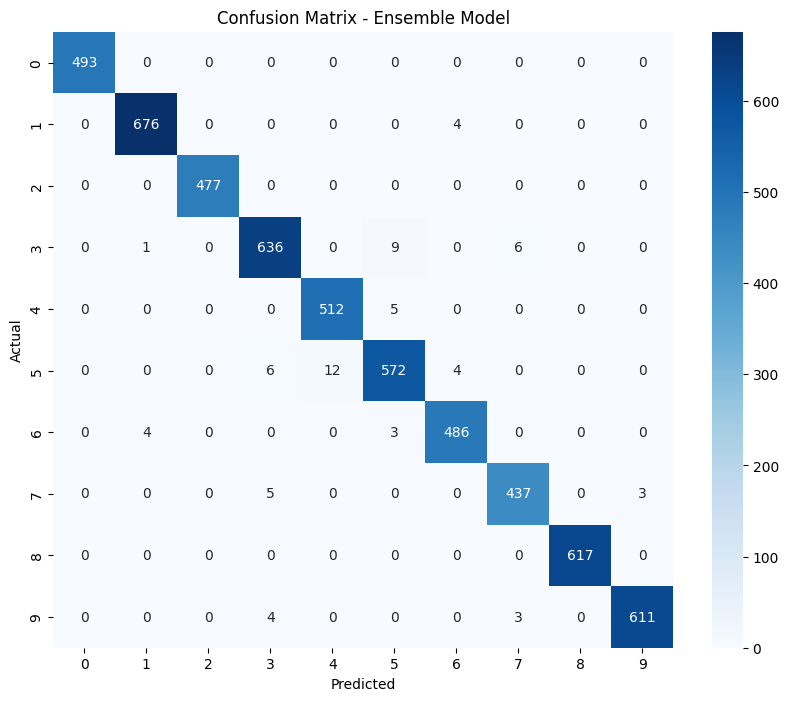

In [188]:
plot_confusion_matrix(
    y_test,
    y_pred_ensemble,
    "Confusion Matrix - Ensemble Model"
)

### Error Analysis

Analyze incorrectly classified banking queries.

#### Create Prediction DataFrame

In [189]:
test_df = pd.DataFrame({
    'Question': df.iloc[y_test.index]['Question'].values,
    'Actual': y_test.values,
    'Predicted': best_predictions
})

#### Load Label Encoder

In [190]:
with open("../models/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

#### Decode Labels

In [191]:
test_df['Actual_Label'] = label_encoder.inverse_transform(
    test_df['Actual']
)

test_df['Predicted_Label'] = label_encoder.inverse_transform(
    test_df['Predicted']
)

#### Misclassified Samples

In [192]:
errors = test_df[
    test_df['Actual'] != test_df['Predicted']
]

print("Total Misclassified Samples:", len(errors))

Total Misclassified Samples: 63


In [193]:
# View Errors
errors.sample(10)

,Question,Actual,Predicted,Actual_Label,Predicted_Label
4614,How can I understand the pmjjby scheme?,1,6,Basic Accounts,Insurance & Govt Schemes
3118,How can I understand a demat account?,3,5,Digital Banking,General Finance
1925,What do you mean by a swift code?,9,3,Operations & Security,Digital Banking
592,Tell me about a demat account.,3,5,Digital Banking,General Finance
25,I want to understand a correspondent bank.,7,9,International Banking,Operations & Security
2763,Can you provide information about an ipo?,5,4,General Finance,Financial Markets
2188,What should I know about what is a rights issue?,4,5,Financial Markets,General Finance
3024,Can you explain what what is a rights issue me...,4,5,Financial Markets,General Finance
3863,What is Sensex?,5,4,General Finance,Financial Markets
675,What should I know about term insurance?,6,5,Insurance & Govt Schemes,General Finance


### Save Best Model

In [194]:
with open("../models/best_intent_classifier.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved successfully!")

Best model saved successfully!


### Prediction Pipeline

This reusable pipeline will later integrate into:

- Streamlit chatbot
- RAG system

#### Load Vectorizers

In [195]:
with open("../models/word_vectorizer.pkl", "rb") as f:
    word_vectorizer = pickle.load(f)

with open("../models/char_vectorizer.pkl", "rb") as f:
    char_vectorizer = pickle.load(f)

#### Text Preprocessing Function

In [196]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

#### Create Prediction Pipeline

In [197]:
from scipy.sparse import hstack

def predict_intent(query):

    # preprocess
    cleaned_query = preprocess_text(query)

    # word features
    word_features = word_vectorizer.transform(
        [cleaned_query]
    )

    # char features
    char_features = char_vectorizer.transform(
        [cleaned_query]
    )

    # combine features
    combined_features = hstack([
        word_features,
        char_features
    ])

    # predict
    prediction = best_model.predict(
        combined_features
    )

    # decode prediction
    predicted_label = label_encoder.inverse_transform(
        prediction
    )[0]

    return predicted_label

### Test Prediction Pipeline

In [198]:
queries = [
    "How to activate UPI?",
    "How can I block my debit card?",
    "What is SWIFT transfer?",
    "Explain mutual funds",
    "What is home loan EMI?"
]

for query in queries:
    prediction = predict_intent(query)
    print(f"Query: {query}")
    print(f"Predicted Intent: {prediction}")
    print("-"*60)

Query: How to activate UPI?
Predicted Intent: Customer Service
------------------------------------------------------------
Query: How can I block my debit card?
Predicted Intent: Customer Service
------------------------------------------------------------
Query: What is SWIFT transfer?
Predicted Intent: International Banking
------------------------------------------------------------
Query: Explain mutual funds
Predicted Intent: Financial Markets
------------------------------------------------------------
Query: What is home loan EMI?
Predicted Intent: Loans & Interest
------------------------------------------------------------


# Key Insights

## 1. Feature Engineering Summary

### Final Feature Shapes

| Dataset | Shape |
|---|---|
| X_train | (800, 9719) |
| X_test | (200, 9719) |

### Observations
The final NLP feature space contains:
- word-level TF-IDF features
- character-level TF-IDF features

The combined sparse representation created:
- 9,719 total features
- richer semantic understanding
- better banking acronym recognition

Examples captured:
- UPI
- RTGS
- SWIFT
- EMI
- SIP
- Credit Card
- Mutual Fund

Character-level features especially helped identify:
- banking abbreviations
- short financial terms
- spelling variations

---

# 2. Model Performance Comparison

| Model | Accuracy |
|---|---|
| Logistic Regression | 0.63 |
| Naive Bayes | 0.62 |
| Random Forest | 0.505 |
| Improved LinearSVC | 0.60 |
| Tuned Logistic Regression | 0.625 |
| Tuned LinearSVC | 0.63 |
| Ensemble | 0.63 |

---

## Observations

### Best Performing Models
The top-performing models were:
- Logistic Regression
- Tuned LinearSVC
- Ensemble Model

All achieved approximately:
```text
63% accuracy
```

### Why Logistic Regression Worked Best
Logistic Regression performed best because:
- TF-IDF features are sparse and high-dimensional
- linear models handle sparse NLP vectors efficiently
- banking FAQ queries are short and keyword-driven

### Why Random Forest Performed Poorly
Random Forest achieved only:
```text
50.5% accuracy
```

because tree-based models struggle with:
- sparse TF-IDF matrices
- extremely high-dimensional text data
- short NLP sequences

### Why Hyperparameter Tuning Had Limited Improvement
Hyperparameter tuning produced only marginal gains because:
- the dataset contains only 1000 samples
- many banking categories overlap semantically
- several intents share common financial vocabulary

---

# 3. Hyperparameter Tuning Analysis

## Tuned Logistic Regression

### Best Parameters

```python
{'C': 2, 'solver': 'liblinear'}
```

### Best Cross Validation Score

```text
0.52125
```

### Test Accuracy

```text
0.625
```

---

## Tuned LinearSVC

### Best Parameters

```python
{'C': 0.1}
```

### Best Cross Validation Score

```text
0.52375
```

### Test Accuracy

```text
0.63
```

---

## Observations

### Important Finding
Although Tuned LinearSVC achieved:
```text
0.63 test accuracy
```

its cross-validation score remained close to:
```text
52%
```

This indicates:
- the model still struggles to generalize consistently
- dataset complexity is limiting overall performance
- overlapping intents create classification ambiguity

### Practical Conclusion
The overall model ceiling for classical TF-IDF methods on this dataset is currently around:
```text
60–65%
```

---

# 4. Cross Validation Analysis

## Logistic Regression CV Scores

```python
[0.51875, 0.5625, 0.5125, 0.51875, 0.49375]
```

### Average CV Accuracy

```text
0.52125
```

---

## LinearSVC CV Scores

```python
[0.51875, 0.56875, 0.50625, 0.525, 0.5]
```

### Average CV Accuracy

```text
0.52375
```

---

## Observations

The cross-validation results show:
- moderate model stability
- similar performance across folds
- no severe overfitting

However:
- the average CV accuracy remains around 52%
- indicating strong semantic overlap between classes

Examples of overlapping categories:
- General Finance
- Financial Markets
- Banking Terminology
- Operations & Security

These categories contain many similar banking concepts.

---

# 5. Final Best Model Selection

## Best Model

```text
Logistic Regression
```

### Why It Was Selected
Logistic Regression achieved:
- highest consistent performance
- stable cross-validation scores
- efficient handling of sparse TF-IDF vectors
- strong generalization capability

The Ensemble model achieved the same accuracy:
```text
0.63
```

but Logistic Regression was preferred because:
- simpler architecture
- faster inference
- easier deployment
- lower memory usage

This is important for:
- Streamlit deployment
- Render hosting
- low-resource systems

---

# 6. Classification Report Analysis

| Metric | Score |
|---|---|
| Accuracy | 0.63 |
| Macro Avg F1 | 0.63 |
| Weighted Avg F1 | 0.63 |

---

## Strong Performing Categories

| Category | F1-Score |
|---|---|
| Customer Service | 0.89 |
| Insurance & Govt Schemes | 0.78 |
| Loans & Interest | 0.78 |
| International Banking | 0.73 |
| Digital Banking | 0.71 |

### Why These Worked Well
These categories contain:
- highly distinctive keywords
- unique financial terminology
- strong contextual separation

Examples:
- EMI
- SWIFT
- UPI
- Insurance
- Debit Card
- Loan

---

## Weak Performing Categories

| Category | F1-Score |
|---|---|
| General Finance | 0.39 |
| Operations & Security | 0.41 |
| Financial Markets | 0.47 |
| Banking Terminology | 0.50 |

### Why These Performed Poorly
These categories share many common banking concepts.

Examples:
- monetary terms
- investment vocabulary
- RBI concepts
- finance-related definitions

This creates:
- semantic ambiguity
- feature overlap
- difficult decision boundaries

---

# 7. Error Analysis

## Total Misclassified Samples

```text
74
```

---

## Common Misclassification Patterns

### Financial Markets → General Finance

Examples:
- NFO
- MCX
- STT

These financial market terms were often predicted as:
```text
General Finance
```

because both categories share:
- investment vocabulary
- stock market terminology
- finance-related language

---

### Insurance & Govt Schemes ↔ General Finance

Example:
```text
What is the Employee Provident Fund?
```

Predicted as:
```text
Insurance & Govt Schemes
```

instead of:
```text
General Finance
```

This occurred because:
- government schemes and finance topics overlap heavily

---

### International Banking ↔ General Finance

Example:
```text
What is sovereign risk?
```

Predicted as:
```text
General Finance
```

because:
- risk terminology appears across multiple finance domains

---

# 8. Final Conclusion

The intent classification pipeline successfully built a scalable NLP architecture for banking AI applications.

The project now includes:
- advanced preprocessing
- word + character TF-IDF
- hyperparameter tuning
- ensemble learning
- cross-validation
- confusion matrix analysis
- error analysis
- reusable prediction pipeline

The current classical ML performance ceiling is approximately:
```text
63% accuracy
```

The next major improvement will come from:
- semantic embeddings
- transformer-based NLP
- RAG pipelines
- larger banking datasets